
# Import Libraries


In [6]:
import numpy as np
from decision_tree import DecisionTreeRegressor
from Bagging import BaggingRegressor
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import time


In [7]:
import os
import pandas as pd

#print('cwd:', os.getcwd())
#print('files:', os.listdir())

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

def prepare_data(df):
    X = df.drop(columns=['Calories']).values  # Chuyển về numpy array
    y = df['Calories'].values                 # Chuyển về numpy array
    return X, y

X_train, y_train = prepare_data(train_df)
X_test, y_test = prepare_data(test_df)

# --- QUAN TRỌNG: LẤY MẪU NHỎ ĐỂ CHẠY THỬ (DEMO) ---
# Vì Decision Tree tự code chạy khá lâu trên 9600 dòng.
# Bạn hãy chạy thử với 1000 dòng trước. Nếu ổn thì comment 3 dòng dưới lại để chạy full.
subset_idx = np.random.choice(len(X_train), 5000, replace=False)
X_train = X_train[subset_idx]
y_train = y_train[subset_idx]
print(f"Training trên tập dữ liệu kích thước: {X_train.shape}")


Training trên tập dữ liệu kích thước: (5000, 7)


## Train 20 cây, độ sâu 10, 5000 lần hỏi

# Bagging Reggressor from scratch

Thời gian huấn luyện: 233.68 giây
Huấn luyện hoàn tất!
------------------------------
Kết quả đánh giá:
RMSE (Sai số trung bình): 4.09 Calories
R2 Score (Độ phù hợp): 0.9959
------------------------------


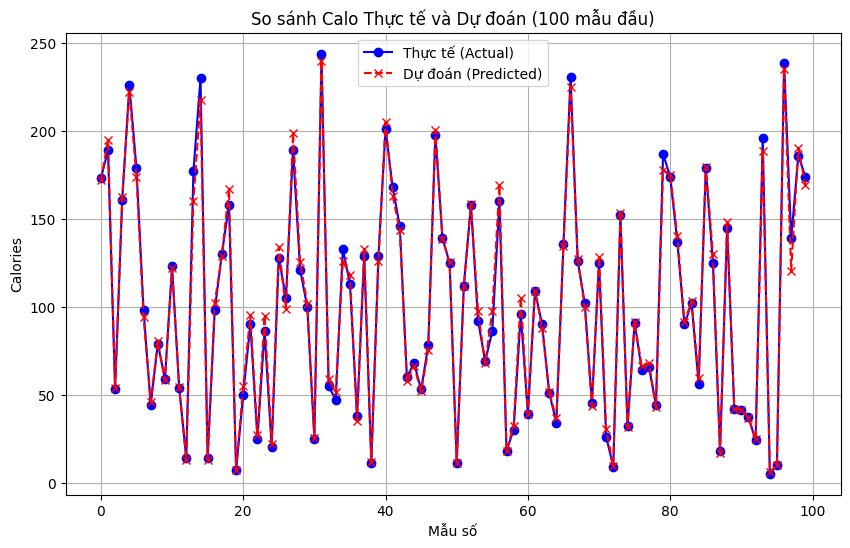

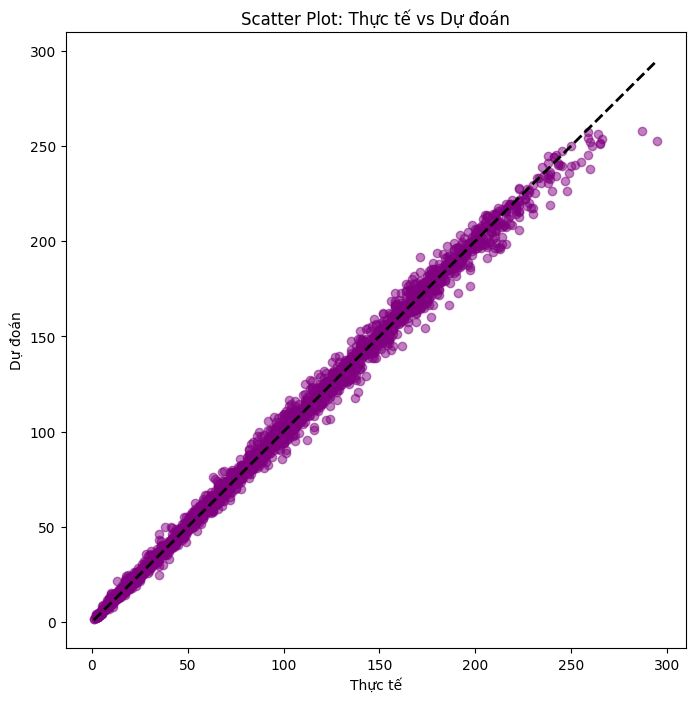

In [8]:
# Khởi tạo Bagging Regressor
# - n_estimators=5: Dùng 5 cây (Tăng lên 10-20 để chính xác hơn nhưng lâu hơn)
# - max_depth=5: Độ sâu cây tối đa (Tăng lên 10 nếu muốn cây học kỹ hơn)
model = BaggingRegressor(base_tree_cls=DecisionTreeRegressor, 
                         n_estimators=20, 
                         min_samples_split=10, 
                         max_depth=10)
start=time.time()
model.fit(X_train, y_train)
Scratch_time=time.time()-start
print(f"Thời gian huấn luyện: {Scratch_time:.2f} giây")
print("Huấn luyện hoàn tất!")

# ==========================================
# PHẦN 4: ĐÁNH GIÁ & VẼ BIỂU ĐỒ
# ==========================================


# Dự đoán trên tập test
y_pred = model.predict(X_test)

# Tính toán sai số
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("-" * 30)
print(f"Kết quả đánh giá:")
print(f"RMSE (Sai số trung bình): {rmse:.2f} Calories")
print(f"R2 Score (Độ phù hợp): {r2:.4f}")
print("-" * 30)

# Vẽ biểu đồ So sánh Thực tế vs Dự đoán
plt.figure(figsize=(10, 6))
# Vẽ 100 điểm đầu tiên cho dễ nhìn
plt.plot(y_test[:100], label='Thực tế (Actual)', color='blue', marker='o')
plt.plot(y_pred[:100], label='Dự đoán (Predicted)', color='red', linestyle='--', marker='x')
plt.title('So sánh Calo Thực tế và Dự đoán (100 mẫu đầu)')
plt.xlabel('Mẫu số')
plt.ylabel('Calories')
plt.legend()
plt.grid(True)
plt.show()

# Vẽ biểu đồ phân tán (Scatter Plot)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Đường chéo chuẩn
plt.xlabel('Thực tế')
plt.ylabel('Dự đoán')
plt.title('Scatter Plot: Thực tế vs Dự đoán')
plt.show()

# Bagging Reggressor using sklearn

# Import Libraries for BaggingRegressor

In [15]:
from sklearn.ensemble import BaggingRegressor as SklearnBaggingRegressor
from sklearn.tree import DecisionTreeRegressor as SklearnDecisionTreeRegressor

Thời gian huấn luyện sklearn: 0.22 giây
Huấn luyện sklearn hoàn tất!
------------------------------
Kết quả đánh giá của mô hình lấy từ thư viện:
RMSE (Sai số trung bình): 4.43 Calories
R2 Score (Độ phù hợp): 0.9951
------------------------------


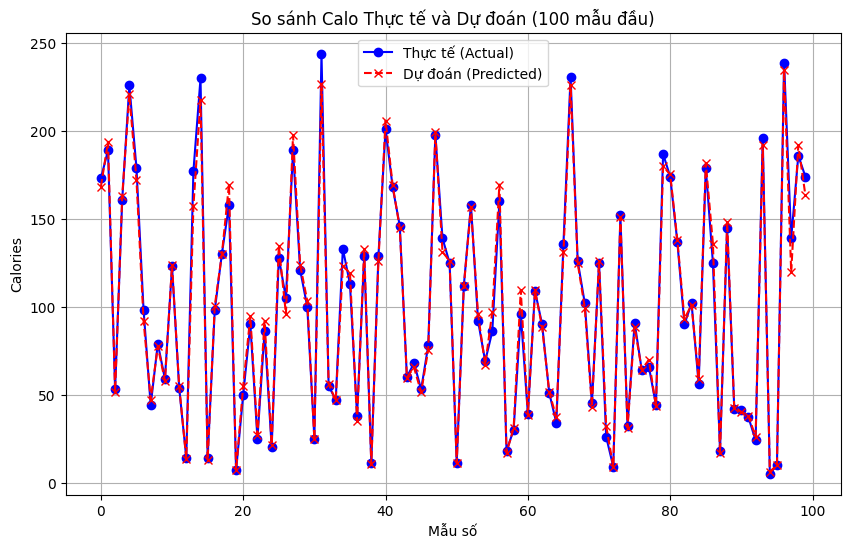

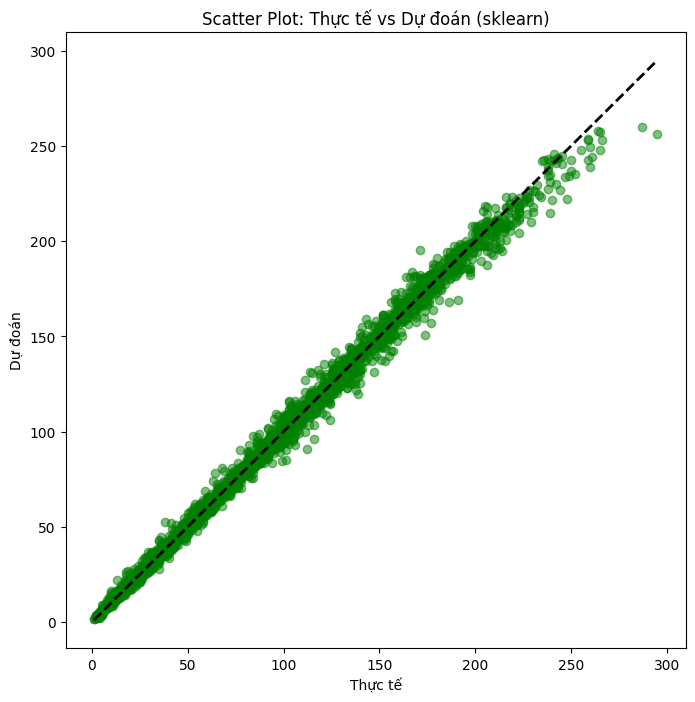

In [19]:
'''
model = SklearnBaggingRegressor(estimator=SklearnDecisionTreeRegressor(max_depth=10),
                         n_estimators=20,
                         random_state=42)
'''
my_tree = SklearnDecisionTreeRegressor(
    max_depth=10,            # Độ sâu (giống code cũ)
    min_samples_split=10,   # <-- Ghi vào đây để giống code cũ
    random_state=42
)


model = SklearnBaggingRegressor(
    estimator=my_tree,      # Đưa cái cây đã cài đặt vào đây
    n_estimators=20,
    random_state=42,
    
)

start=time.time()
model.fit(X_train, y_train)
sk_learn_time=time.time()-start
print(f"Thời gian huấn luyện sklearn: {sk_learn_time:.2f} giây")
print("Huấn luyện sklearn hoàn tất!")
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("-" * 30)
print(f"Kết quả đánh giá của mô hình lấy từ thư viện:")
print(f"RMSE (Sai số trung bình): {rmse:.2f} Calories")
print(f"R2 Score (Độ phù hợp): {r2:.4f}")
print("-" * 30)

plt.figure(figsize=(10, 6))
# Vẽ 100 điểm đầu tiên cho dễ nhìn
plt.plot(y_test[:100], label='Thực tế (Actual)', color='blue', marker='o')
plt.plot(y_pred[:100], label='Dự đoán (Predicted)', color='red', linestyle='--', marker='x')
plt.title('So sánh Calo Thực tế và Dự đoán (100 mẫu đầu)')
plt.xlabel('Mẫu số')
plt.ylabel('Calories')
plt.legend()
plt.grid(True)
plt.show()

# Vẽ biểu đồ phân tán (Scatter Plot)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Đường chéo chuẩn
plt.xlabel('Thực tế')
plt.ylabel('Dự đoán')
plt.title('Scatter Plot: Thực tế vs Dự đoán (sklearn)')
plt.show()